# Simulated verificaition of dynamics on SWING PHASE

In [1]:
# Import necessary libraries
import numpy as np
import matplotlib.pyplot as plt
import os
import math
import scipy.io as sio
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
import ipywidgets as widgets
from IPython.display import display
import rootpath
import numpy as np
from scipy.io import loadmat


In [2]:
# Data from theotical sim (Matlab)
t_bias = 10     # time shift for the sim exp start from 10s
t_sim_list = np.load('data/swing_exp_data_t.npy', allow_pickle=True) - t_bias
theta1_sim_list = np.load('data/swing_exp_data_theta1.npy', allow_pickle=True)
theta2_sim_list = np.load('data/swing_exp_data_theta2.npy', allow_pickle=True)

# Data from equivalent sim (Matlab)
data = loadmat('data/matlab_theo/swing_expdata.mat', simplify_cells=True)
t_all = data['t_all']       # 10000 * n (list of array)
Xt_all = data['Xt_all']     # 10000 * n * 4 (list of 2d array)

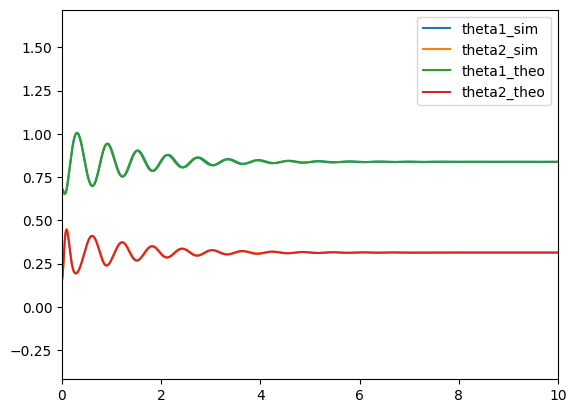

In [3]:
# Test One Group
exp_id = 11
plt.plot(t_sim_list[exp_id], theta1_sim_list[exp_id], label='theta1_sim')
plt.plot(t_sim_list[exp_id], theta2_sim_list[exp_id], label='theta2_sim')
plt.plot(t_all[exp_id], Xt_all[exp_id][:, 0], label='theta1_theo')
plt.plot(t_all[exp_id], Xt_all[exp_id][:, 1], label='theta2_theo')
plt.xlim(0, 10)
plt.legend()

In [4]:
# step_response_compare Function; point data for indexing
Theta1_array = np.linspace(math.pi/6, math.pi*2/3, 10)
Theta2_array = np.linspace(0, math.pi/2, 10)
StartPointArray = []
for theta_1 in Theta1_array:
  for theta_2 in Theta2_array:
    StartPointArray.append([theta_1, theta_2])
StartPointArray = np.array(StartPointArray)
EndPointArray = StartPointArray

def step_response_compare(t_array_matlab, theta1_array_matlab, theta2_array_matlab, t_array_mujoco, theta1_array_mujoco, theta2_array_mujoco):
  """
  Compare the step response between theoretical (Matlab) and simulated (Mujoco) data.

  Parameters:
  - t_array_matlab (numpy.ndarray): Time array for Matlab data.
  - theta1_array_matlab (numpy.ndarray): Theta1 values from Matlab data.
  - theta2_array_matlab (numpy.ndarray): Theta2 values from Matlab data.
  - t_array_mujoco (numpy.ndarray): Time array for Mujoco data.
  - theta1_array_mujoco (numpy.ndarray): Theta1 values from Mujoco data.
  - theta2_array_mujoco (numpy.ndarray): Theta2 values from Mujoco data.

  Returns:
  - dict: A dictionary containing:
    - 'valid' (bool): Whether the data is within valid ranges.
    - 'RMSE_theta1' (float): Root Mean Square Error for Theta1.
    - 'RMSE_theta2' (float): Root Mean Square Error for Theta2.
    - 'MAE_theta1' (float): Mean Absolute Error for Theta1.
    - 'MAE_theta2' (float): Mean Absolute Error for Theta2.
    - 'MaxAE_theta1' (float): Maximum Absolute Error for Theta1.
    - 'MaxAE_theta2' (float): Maximum Absolute Error for Theta2.
  """
  # Calculate the MSE using interpolation over the interval [0-10s]
  t_intervel = np.linspace(0, 10, 1000)
  theta1_sim_intervel = np.interp(t_intervel, t_array_mujoco, theta1_array_mujoco)
  theta2_sim_intervel = np.interp(t_intervel, t_array_mujoco, theta2_array_mujoco)
  theta1_theo_intervel = np.interp(t_intervel, t_array_matlab, theta1_array_matlab)
  theta2_theo_intervel = np.interp(t_intervel, t_array_matlab, theta2_array_matlab)

  # Check validity of data
  valid = True
  min_theta1 = min(np.min(theta1_sim_intervel), np.min(theta1_theo_intervel))
  max_theta1 = max(np.max(theta1_sim_intervel), np.max(theta1_theo_intervel))
  min_theta2 = min(np.min(theta2_sim_intervel), np.min(theta2_theo_intervel))
  max_theta2 = max(np.max(theta2_sim_intervel), np.max(theta2_theo_intervel))
  threshold = math.pi / 180  # 1 degree in radians
  if ((np.pi / 6 + threshold) >= min_theta1 or 
    max_theta1 >= (np.pi / 6 + 2 / 3 * np.pi - threshold) or 
    (0 + threshold) >= min_theta2 or 
    max_theta2 >= (0 + 2 / 3 * np.pi - threshold)):
    valid = False

  # Calculate errors
  RMSE_theta1 = np.sqrt(np.mean(np.square(theta1_sim_intervel - theta1_theo_intervel)))
  RMSE_theta2 = np.sqrt(np.mean(np.square(theta2_sim_intervel - theta2_theo_intervel)))
  MAE_theta1 = np.mean(np.abs(theta1_sim_intervel - theta1_theo_intervel))
  MAE_theta2 = np.mean(np.abs(theta2_sim_intervel - theta2_theo_intervel))
  MaxAE_theta1 = np.max(np.abs(theta1_sim_intervel - theta1_theo_intervel))
  MaxAE_theta2 = np.max(np.abs(theta2_sim_intervel - theta2_theo_intervel))

  return {
    'valid': valid,
    'RMSE_theta1': RMSE_theta1,
    'RMSE_theta2': RMSE_theta2,
    'MAE_theta1': MAE_theta1,
    'MAE_theta2': MAE_theta2,
    'MaxAE_theta1': MaxAE_theta1,
    'MaxAE_theta2': MaxAE_theta2
  }

# Test it
step_response_compare(
  t_all[exp_id], 
  Xt_all[exp_id][:, 0], 
  Xt_all[exp_id][:, 1], 
  t_sim_list[exp_id], 
  theta1_sim_list[exp_id], 
  theta2_sim_list[exp_id]
)

{'valid': True,
 'RMSE_theta1': np.float64(0.003458671287069834),
 'RMSE_theta2': np.float64(0.0026552866634717434),
 'MAE_theta1': np.float64(0.0024819196909152846),
 'MAE_theta2': np.float64(0.001592114072842752),
 'MaxAE_theta1': np.float64(0.010401617544056885),
 'MaxAE_theta2': np.float64(0.016893482998113052)}

In [6]:
# Calculate the error for all data, save in csv file
swing_error_list = []
for i in tqdm(range(len(t_all))):
  result = step_response_compare(
    t_all[i], 
    Xt_all[i][:, 0], 
    Xt_all[i][:, 1], 
    t_sim_list[i], 
    theta1_sim_list[i], 
    theta2_sim_list[i]
  )
  swing_error_list.append(result)
# save as pd
swing_error_list = pd.DataFrame(swing_error_list)
swing_error_list.to_csv('data/swing_error_list.csv', index=False)

100%|██████████| 10000/10000 [00:01<00:00, 5668.29it/s]


In [7]:
# Load saved data and analysis
swing_error_list = pd.read_csv('data/swing_error_list.csv')
swing_error_valid = swing_error_list.query('valid==True')
swing_error_valid       # 5283 experiments data is valid

,valid,RMSE_theta1,RMSE_theta2,MAE_theta1,MAE_theta2,MaxAE_theta1,MaxAE_theta2
0,True,0.001077,0.003225,0.001074,0.003225,0.001485,0.003404
1,True,0.001765,0.001746,0.001486,0.001433,0.004342,0.010677
2,True,0.002886,0.002160,0.002290,0.001289,0.007253,0.018219
3,True,0.004004,0.003245,0.003116,0.002111,0.009723,0.027681
4,True,0.004921,0.004271,0.003814,0.002869,0.011557,0.036373
...,...,...,...,...,...,...,...
9995,True,0.001749,0.005167,0.001378,0.004321,0.007334,0.033349
9996,True,0.001529,0.004281,0.001347,0.003801,0.005704,0.024268
9997,True,0.001266,0.003756,0.001187,0.003553,0.003714,0.016722
9998,True,0.000895,0.003662,0.000882,0.003615,0.001653,0.010273


In [8]:
# Summary
max_RMSE_theta1 = swing_error_valid['RMSE_theta1'].max()
max_RMSE_theta2 = swing_error_valid['RMSE_theta2'].max()
max_MAE_theta1 = swing_error_valid['MAE_theta1'].max()
max_MAE_theta2 = swing_error_valid['MAE_theta2'].max()
max_MaxAE_theta1 = swing_error_valid['MaxAE_theta1'].max()
max_MaxAE_theta2 = swing_error_valid['MaxAE_theta2'].max()
# save to error_summary file
error_summary = {
  'max_RMSE_theta1': max_RMSE_theta1,
  'max_RMSE_theta2': max_RMSE_theta2,
  'max_MAE_theta1': max_MAE_theta1,
  'max_MAE_theta2': max_MAE_theta2,
  'max_MaxAE_theta1': max_MaxAE_theta1,
  'max_MaxAE_theta2': max_MaxAE_theta2
}
error_summary = pd.DataFrame(error_summary, index=[0])
error_summary.to_csv('data/swing_error_summary.csv', index=False)
error_summary


,max_RMSE_theta1,max_RMSE_theta2,max_MAE_theta1,max_MAE_theta2,max_MaxAE_theta1,max_MaxAE_theta2
0,0.011595,0.015693,0.005856,0.013174,0.06869,0.149943


In [ ]:
# 创建滑动条
si_slider = widgets.IntSlider(value=22, min=0, max=99, step=1, description='StartPoint_index')
ei_slider = widgets.IntSlider(value=55, min=0, max=99, step=1, description='EndPoint_index')

from matplotlib import rcParams

config = {
    "font.family":'Times New Roman',  # 设置字体类型
    "axes.unicode_minus": False, #解决负号无法显示的问题
    "font.size": 16,  # 设置字体大小
}
rcParams.update(config)

legendSet = {
    'loc': 'upper right',
    'fontsize': 12,
}


# 绘图函数
def update_plot(si, ei):
    # Force
    print(f"StartPoint: {StartPointArray[si]}, EndPoint: {EndPointArray[ei]}")

    # 获取数据
    t_mujoco, theta1_mujoco, theta2_mujoco = get_mujoco_data(si, ei)
    t_matlab, theta1_matlab, theta2_matlab = get_matlab_data(si, ei)
    

    # 0-10做插值
    t_interp = np.linspace(0, 10, 1000)
    theta1_mujoco = np.interp(t_interp, t_mujoco, theta1_mujoco)
    theta2_mujoco = np.interp(t_interp, t_mujoco, theta2_mujoco)
    theta1_matlab = np.interp(t_interp, t_matlab, theta1_matlab)
    theta2_matlab = np.interp(t_interp, t_matlab, theta2_matlab)    
    
    fig, axs = plt.subplots(2, 2, figsize=(12, 12), dpi=200)  # 两行两列的图布局
    
    # --- 左上：时间曲线 ---
    # axs[0, 0].plot(t_interp, theta1_mujoco, label='Mujoco theta1')
    axs[0, 0].plot(t_interp, theta2_mujoco, label='Equi-Mujoco')
    # axs[0, 0].plot(t_interp, theta1_matlab, label='Matlab theta1')
    axs[0, 0].plot(t_interp, theta2_matlab, label='Theo-Matlab')
    axs[0, 0].set_xlabel('Time/s')
    axs[0, 0].set_ylabel('Theta2/rad')
    axs[0, 0].set_title('Theta2 vs Time')

    # 绘制角度限制横线
    # axs[0, 0].axhline(y=math.pi*2/3, color='r', linestyle='--', label='Theta1 Limit')
    # axs[0, 0].axhline(y=math.pi/6, color='r', linestyle='--', label='Theta2 Limit')
    # axs[0, 0].axhline(y=math.pi/2, color='b', linestyle='--', label='Theta2 Zero')
    # axs[0, 0].axhline(y=0, color='b', linestyle='--', label='Theta1 Start')

    # 标注起始点
    axs[0, 0].scatter(t_interp[0], theta2_mujoco[0], s=100, color='purple', label='Start Point', marker='*', alpha=0.9, zorder=5)
    axs[0, 0].scatter(t_interp[-1], theta2_mujoco[-1], s=100, color='red', label='End Point', marker='*', alpha=0.9, zorder=5)
    axs[0, 0].legend(**legendSet)

    edge = math.pi/3*0
    axs[0, 0].set_ylim([0, math.pi/2])
    
    # --- 右上：轨迹图 ---
    axs[0, 1].plot(theta1_mujoco, theta2_mujoco, label='Equivalent Sim', alpha=0.6)  # 连线
    axs[0, 1].scatter(theta1_mujoco, theta2_mujoco, s=3, label='Equivalent-Point')  # 散点

    axs[0, 1].plot(theta1_matlab, theta2_matlab, label='Theoretical Sim', alpha=0.6)  # 连线
    axs[0, 1].scatter(theta1_matlab, theta2_matlab, s=3, label='Theoretical-Point')  # 散点


    # 绘制角度方格——一个方形        
    # rect = plt.Rectangle((math.pi/6, 0), math.pi*2/3-math.pi/6, math.pi/2, linewidth=1, edgecolor='r', facecolor='none')
    # axs[0, 1].add_patch(rect)
    
    axs[0, 1].set_xlabel('Theta1/rad')
    axs[0, 1].set_ylabel('Theta2/rad')
    axs[0, 1].set_title('Theta Trajectory')
    axs[0, 1].set_xlim([math.pi/6-edge, math.pi*2/3+edge])
    axs[0, 1].set_ylim([0-edge, math.pi/2+edge])

    # draw all the grid point-StartPointArray
    for i in range(len(StartPointArray)):
        axs[0, 1].scatter(StartPointArray[i][0], StartPointArray[i][1], s=3, color='green', alpha=0.5)
        # axs[0, 1].text(StartPointArray[i][0], StartPointArray[i][1], str(i), fontsize=8, color='green')

    # end point 
    axs[0, 1].scatter(theta1_mujoco[0], theta2_mujoco[0], s=100, color='purple', label='Start Point', marker='*', alpha=0.9, zorder=5)
    axs[0, 1].scatter(theta1_mujoco[-1], theta2_mujoco[-1], s=100, color='red', label='End Point', marker='*', alpha=0.9, zorder=5)
    axs[0, 1].grid(True, linestyle='--', alpha=0.5)
    
    axs[0, 1].legend(**legendSet)

    
    # --- 左下：a_1cos(theta1) + a_2cos(theta2) ---
    a1 = 0.25  # 你可以根据需要调整
    a2 = 0.25  # 你可以根据需要调整
    flip = -1  # You can adjust this value as needed

    x_mujoco = (a1 * np.cos(theta1_mujoco) + a2 * np.cos(theta2_mujoco + theta1_mujoco)) * flip
    y_mujoco = (a1 * np.sin(theta1_mujoco) + a2 * np.sin(theta2_mujoco + theta1_mujoco)) * flip
    x_matlab = (a1 * np.cos(theta1_matlab) + a2 * np.cos(theta2_matlab + theta1_matlab)) * flip
    y_matlab = (a1 * np.sin(theta1_matlab) + a2 * np.sin(theta2_matlab + theta1_matlab)) * flip

    knee_x_mujoco = (a1 * np.cos(theta1_mujoco))*flip
    knee_y_mujoco = (a1 * np.sin(theta1_mujoco))*flip
    knee_x_matlab = (a1 * np.cos(theta1_matlab))*flip
    knee_y_matlab = (a1 * np.sin(theta1_matlab))*flip

    zero_ = np.zeros_like(knee_x_mujoco)

    axs[1, 0].plot(x_mujoco, y_mujoco, label='Equivalent Trajectory')
    axs[1, 0].plot(x_matlab, y_matlab, label='Theoretical Trajectory')

    # interesting point
    index_interesting = [0, -1, len(t_interp)//30, len(t_interp)//100]
    
    for index in index_interesting:
        axs[1, 0].plot([zero_[index], knee_x_mujoco[index], x_mujoco[index]], [zero_[index], knee_y_mujoco[index], y_mujoco[index]], '-' if index < 2 else '--', color='purple', markersize=10, alpha=1 if index < 2 else 0.8)

    # 标注起始点
    axs[1, 0].scatter(x_mujoco[0], y_mujoco[0], s=100, color='purple', label='Start Point', marker='*', alpha=0.9, zorder=5)
    axs[1, 0].scatter(x_mujoco[-1], y_mujoco[-1], s=100, color='red', label='End Point', marker='*', alpha=0.9, zorder=5)

    axs[1, 0].set_xlabel('x/m')
    axs[1, 0].set_ylabel('y/m')

    axs[1, 0].set_xlim([-0.3, 0.3])
    axs[1, 0].set_ylim(np.array([0.5, -0.1])*flip)
    axs[1, 0].set_title('Foot Trajectory')
    axs[1, 0].grid(True, linestyle='--', alpha=0.5)
    axs[1, 0].legend(**legendSet)


    # --- 右下：theta2随时间变化 ---
    axs[1, 1].plot(theta1_mujoco, t_interp, label='Equivalent Theta1')
    axs[1, 1].plot(theta1_matlab, t_interp, label='Theoretical Theta1')
    
    axs[1, 1].set_xlabel('Theta1/rad')
    axs[1, 1].set_ylabel('Time/s')

    # 标注起始点
    axs[1, 1].scatter(theta1_mujoco[0], t_interp[0], s=100, color='purple', label='Start Point', marker='*', alpha=0.9, zorder=5)
    axs[1, 1].scatter(theta1_mujoco[-1], t_interp[-1], s=100, color='red', label='End Point', marker='*', alpha=0.9, zorder=5)

    axs[1, 1].legend(**legendSet)
    axs[1, 1].set_title('Theta1 vs Time')
    axs[1, 1].set_xlim([math.pi/6, math.pi*2/3])

    plt.tight_layout()
    plt.show()

# 显示交互绘图
interactive_plot = widgets.interactive(update_plot, si=si_slider, ei=ei_slider)
display(interactive_plot)

In [ ]:
# TODO
import ipywidgets as widgets
from IPython.display import display

# 创建滑动条
si_slider = widgets.IntSlider(value=31, min=0, max=99, step=1, description='StartPoint_index')
ei_slider = widgets.IntSlider(value=62, min=0, max=99, step=1, description='EndPoint_index')

# 绘图函数
def update_plot(si, ei):
    # if ei < si:
    #     ei = si
    
    # 获取数据
    t_mujoco, theta1_mujoco, theta2_mujoco = get_mujoco_data(si, ei)
    t_matlab, theta1_matlab, theta2_matlab = get_matlab_data(si, ei)

    # 0-10做插值
    t_interp = np.linspace(0, 10, 1000)
    theta1_mujoco = np.interp(t_interp, t_mujoco, theta1_mujoco)
    theta2_mujoco = np.interp(t_interp, t_mujoco, theta2_mujoco)
    theta1_matlab = np.interp(t_interp, t_matlab, theta1_matlab)
    theta2_matlab = np.interp(t_interp, t_matlab, theta2_matlab)    
    
    fig, axs = plt.subplots(1, 2, figsize=(12, 5))  # 两个图：时间曲线 + 轨迹图
    
    # --- 左侧：时间曲线 ---
    axs[0].plot(t_interp, theta1_mujoco, label='Mujoco theta1')
    axs[0].plot(t_interp, theta2_mujoco, label='Mujoco theta2')
    axs[0].plot(t_interp, theta1_matlab, label='Matlab theta1')
    axs[0].plot(t_interp, theta2_matlab, label='Matlab theta2')
    
    axs[0].set_xlabel('Time')
    axs[0].set_ylabel('Theta Values')
    axs[0].legend()
    axs[0].set_title('Theta over Time')

    # 绘制角度限制横线
    axs[0].axhline(y=math.pi*2/3, color='r', linestyle='--', label='Theta1 Limit')
    axs[0].axhline(y=math.pi/6, color='r', linestyle='--', label='Theta2 Limit')
    axs[0].axhline(y=math.pi/2, color='b', linestyle='--', label='Theta2 Zero')
    axs[0].axhline(y=0, color='b', linestyle='--', label='Theta1 Start')

    edge = math.pi/3*0
    axs[0].set_ylim([0-edge, math.pi*2/3+edge])
    
    # --- 右侧：轨迹图 ---
    # axs[1].scatter(theta1_mujoco, theta2_mujoco, label='Mujoco Trajectory', c=t_interp, cmap='viridis', s=5)
    # axs[1].scatter(theta1_matlab, theta2_matlab, label='Matlab Trajectory', c=t_interp, cmap='plasma', s=5)
    # Mujoco Trajectory：连线+散点
    axs[1].plot(theta1_mujoco, theta2_mujoco, color='blue', label='Mujoco Trajectory')  # 连线
    sc1 = axs[1].scatter(theta1_mujoco, theta2_mujoco, s=3, label='Mujoco Points')  # 散点

    # Matlab Trajectory：连线+散点
    axs[1].plot(theta1_matlab, theta2_matlab, color='orange', label='Matlab Trajectory')  # 连线
    sc2 = axs[1].scatter(theta1_matlab, theta2_matlab, s=3, label='Matlab Points')  # 散点

    # 添加颜色条，增强可读性
    # cbar1 = plt.colorbar(sc1, ax=axs[1])
    # cbar1.set_label('Time (Mujoco)', rotation=270, labelpad=15)

    # cbar2 = plt.colorbar(sc2, ax=axs[1])
    # cbar2.set_label('Time (Matlab)', rotation=270, labelpad=15)
    
    axs[1].set_xlabel('Theta1')
    axs[1].set_ylabel('Theta2')
    axs[1].legend()
    axs[1].set_title('Theta1 vs Theta2 Trajectory')

    # 绘制角度方格——一个方形        
    rect = plt.Rectangle((math.pi/6, 0), math.pi*2/3-math.pi/6, math.pi/2, linewidth=1, edgecolor='r', facecolor='none')
    axs[1].add_patch(rect)
    
    axs[1].set_xlim([math.pi/6-edge, math.pi*2/3+edge])
    axs[1].set_ylim([0-edge, math.pi/2+edge])

    # 绘制格点


    plt.tight_layout()
    plt.show()

# 显示交互绘图
interactive_plot = widgets.interactive(update_plot, si=si_slider, ei=ei_slider)
display(interactive_plot)

interactive(children=(IntSlider(value=31, description='StartPoint_index', max=99), IntSlider(value=62, descrip…